# Import

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tikzplotlib

# Results directory

In [2]:
RESULTS_DIR = Path("results/time_per_it_3")

# File

In [3]:
DATA = RESULTS_DIR / "compromise_results.csv"
COLLECTIVE = RESULTS_DIR / "collective_results.csv"
PATH = RESULTS_DIR / "path_results.csv"

# Read files

In [4]:
df = pd.read_csv(DATA)
df_collective = pd.read_csv(COLLECTIVE)
df_path = pd.read_csv(PATH)

In [5]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective
0,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,False,2,0,0.121293,0.0
1,3,100,0,1,0,2,0,0,10,True,...,False,NaN,0,0,1,True,0,0,0.127679,0.0
2,3,100,3,1,3,2,0,3,10,True,...,False,NaN,3,3,1,False,3,0,0.141361,1.0
3,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,True,2,0,0.145296,0.0
4,3,100,1,1,1,2,0,1,10,True,...,False,NaN,1,1,1,False,1,0,0.200771,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9043,4,100,21,2,21,3,0,21,30,True,...,False,NaN,21,21,1,True,21,0,600.145870,inf
9044,4,100,21,2,21,3,0,21,30,True,...,False,NaN,21,21,1,False,21,0,600.169295,inf
9045,4,100,11,2,11,3,0,11,30,True,...,False,NaN,11,11,1,False,11,0,600.223179,inf
9046,4,100,23,2,23,3,0,23,30,True,...,False,NaN,23,23,1,True,23,0,600.192432,inf


In [6]:
df_collective

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie,Mie_config,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Time,Objective
0,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,False,2,0,0.121293,0.0
1,3,100,0,1,0,2,0,0,10,True,...,False,NaN,0,0,1,True,0,0,0.127679,0.0
2,3,100,3,1,3,2,0,3,10,True,...,False,NaN,3,3,1,False,3,0,0.141361,1.0
3,3,100,2,1,2,2,0,2,10,True,...,False,NaN,2,2,1,True,2,0,0.145296,0.0
4,3,100,1,1,1,2,0,1,10,True,...,False,NaN,1,1,1,False,1,0,0.200771,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9043,4,100,21,2,21,3,0,21,30,True,...,False,NaN,21,21,1,True,21,0,600.145870,inf
9044,4,100,21,2,21,3,0,21,30,True,...,False,NaN,21,21,1,False,21,0,600.169295,inf
9045,4,100,11,2,11,3,0,11,30,True,...,False,NaN,11,11,1,False,11,0,600.223179,inf
9046,4,100,23,2,23,3,0,23,30,True,...,False,NaN,23,23,1,True,23,0,600.192432,inf


In [7]:
df_path

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Mie_id,Mc_id,Nb_Mcp,Path,P_id,It,Dm_id,Time,Length,Model_Length
0,3,100,3,1,3,2,0,3,10,True,...,3,3,1,True,3,0,1,0.000004,1.0,2.0
1,3,100,2,1,2,2,0,2,10,True,...,2,2,1,True,2,0,0,0.000004,0.0,2.0
2,3,100,0,1,0,2,0,0,10,True,...,0,0,1,True,0,0,0,0.000003,0.0,2.0
3,3,100,1,1,1,2,0,1,10,True,...,1,1,1,True,1,0,1,0.000003,0.0,2.0
4,3,100,3,1,3,2,0,3,10,True,...,3,3,1,True,3,0,0,0.000006,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9993,4,100,25,2,25,3,0,25,30,True,...,25,25,1,True,25,0,2,0.000005,1.0,2.0
9994,4,100,25,2,25,3,0,25,30,True,...,25,25,1,True,25,0,1,3.151706,1.0,5.0
9995,4,100,22,2,22,3,0,22,30,True,...,22,22,1,True,22,1,1,0.000003,0.0,2.0
9996,4,100,22,2,22,3,0,22,30,True,...,22,22,1,True,22,1,0,2.349246,1.0,4.0


# New attributes

In [8]:
df["Gen"] = np.array(["Homogene", "Heterogene"])[df["Group"] % 2]
df["Accept"] = np.array(["Conservative", "Tolerant"])[df["Group"] % 2]

df["Changes_Prop"] = df["Changes"] / (df["N_bc"] * df["Group_size"])

df_collective["Objective_Prop"] = df_collective["Objective"] / df_collective["N_bc"]

# Filter

In [9]:
# dff = df[df["Fitness_train"] == 1]
# dff = df[df["N_tr"].isin([10, 20, 30, 80, 90, 100])]
# dff = df[df["N_tr"] % 20 == 0]
dff = df
dff = dff[~df["Mie"]]
dff = dff.drop(columns=["Mie", "Mie_id"])
# dff = dff[dff["Group_size"] == 2]
dff = dff[dff["Ko"] <= 3]
dff = dff[dff["Gen"] == "Homogene"]
dff = dff[dff["Path"]]
# dff = dff[dff["Compromise"]]

In [10]:
dff

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Nb_Mcp,Path,P_id,Compromise,Time,It,Changes,Gen,Accept,Changes_Prop
0,3,100,0,1,0,2,0,0,10,True,...,1,True,0,True,0.980672,1,0,Homogene,Conservative,0.000000
1,3,100,2,1,2,2,0,2,10,True,...,1,True,2,True,1.019331,1,0,Homogene,Conservative,0.000000
6,3,100,3,1,3,2,0,3,10,True,...,1,True,3,True,1.041217,1,2,Homogene,Conservative,0.100000
7,3,100,5,1,5,2,0,5,10,True,...,1,True,5,True,0.997204,1,0,Homogene,Conservative,0.000000
8,3,100,1,1,1,2,0,1,10,True,...,1,True,1,True,1.738588,1,1,Homogene,Conservative,0.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5884,4,100,24,2,24,3,0,24,30,True,...,1,True,24,True,83.487489,1,5,Homogene,Conservative,0.055556
5886,4,100,18,2,18,3,0,18,30,True,...,1,True,18,False,601.265364,1,0,Homogene,Conservative,0.000000
5889,4,100,19,2,19,3,0,19,30,True,...,1,True,19,False,600.408300,1,0,Homogene,Conservative,0.000000
5891,4,100,21,2,21,3,0,21,30,True,...,1,True,21,False,600.759716,1,0,Homogene,Conservative,0.000000


# Merge data

In [11]:
# df = pd.merge(
#     df_mip,
#     df_path,
#     how="left",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mc_id",
#         "Path",
#         "P_id",
#         "It"
#     ],
#     suffixes=["_mip", "_path"],
# )


df_compromise_path = dff[dff["Path"]]
df_compromise_path = df_compromise_path[df_compromise_path["Compromise"]]
df_compromise_path_index = df_compromise_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)
df_compromise_no_path = dff[~dff["Path"]]
df_compromise_no_path = df_compromise_no_path[df_compromise_no_path["Compromise"]]
df_compromise_no_path_index = df_compromise_no_path.drop(
    columns=["Path", "Compromise", "Time", "It", "Changes", "Changes_Prop"]
)

df_compromise_index = pd.merge(
    df_compromise_path_index,
    df_compromise_no_path_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
)

df_compromise_path = pd.merge(
    df_compromise_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

df_compromise_no_path = pd.merge(
    df_compromise_no_path,
    df_compromise_index,
    how="inner",
    on=[
        "M",
        "N_tr",
        "Atr_id",
        "Ko",
        "Mo_id",
        "Group_size",
        "Group",
        "Mi_id",
        "N_bc",
        "Same_alt",
        "D_id",
        "Config",
        "P_id",
        "Mc_id",
        "P_id",
        "Gen",
        "Accept",
    ],
    suffixes=["", ""],
)

# df_compromise = pd.merge(
#     df_compromise_path,
#     df_compromise_no_path,
#     how="inner",
#     on=[
#         "M",
#         "N_tr",
#         "Atr_id",
#         "Ko",
#         "Mo_id",
#         "Group_size",
#         "Group",
#         "Mi_id",
#         "N_bc",
#         "Same_alt",
#         "D_id",
#         "Config",
#         "Mie",
#         "P_id",
#         "Mie_id",
#         "Mc_id",
#         "P_id",
#         "Gen",
#         "Accept"
#     ],
#     suffixes=["_path", "_no_path"],
# )

df_compromise = pd.concat([df_compromise_path, df_compromise_no_path])

df_compromise

,M,N_tr,Atr_id,Ko,Mo_id,Group_size,Group,Mi_id,N_bc,Same_alt,...,Changes,Gen,Accept,Changes_Prop,Method_x,Mie_config_x,Nb_Mcp_x,Method_y,Mie_config_y,Nb_Mcp_y


# Plot

Text(0.5, 0.98, 'Proportion of instances reaching compromise')

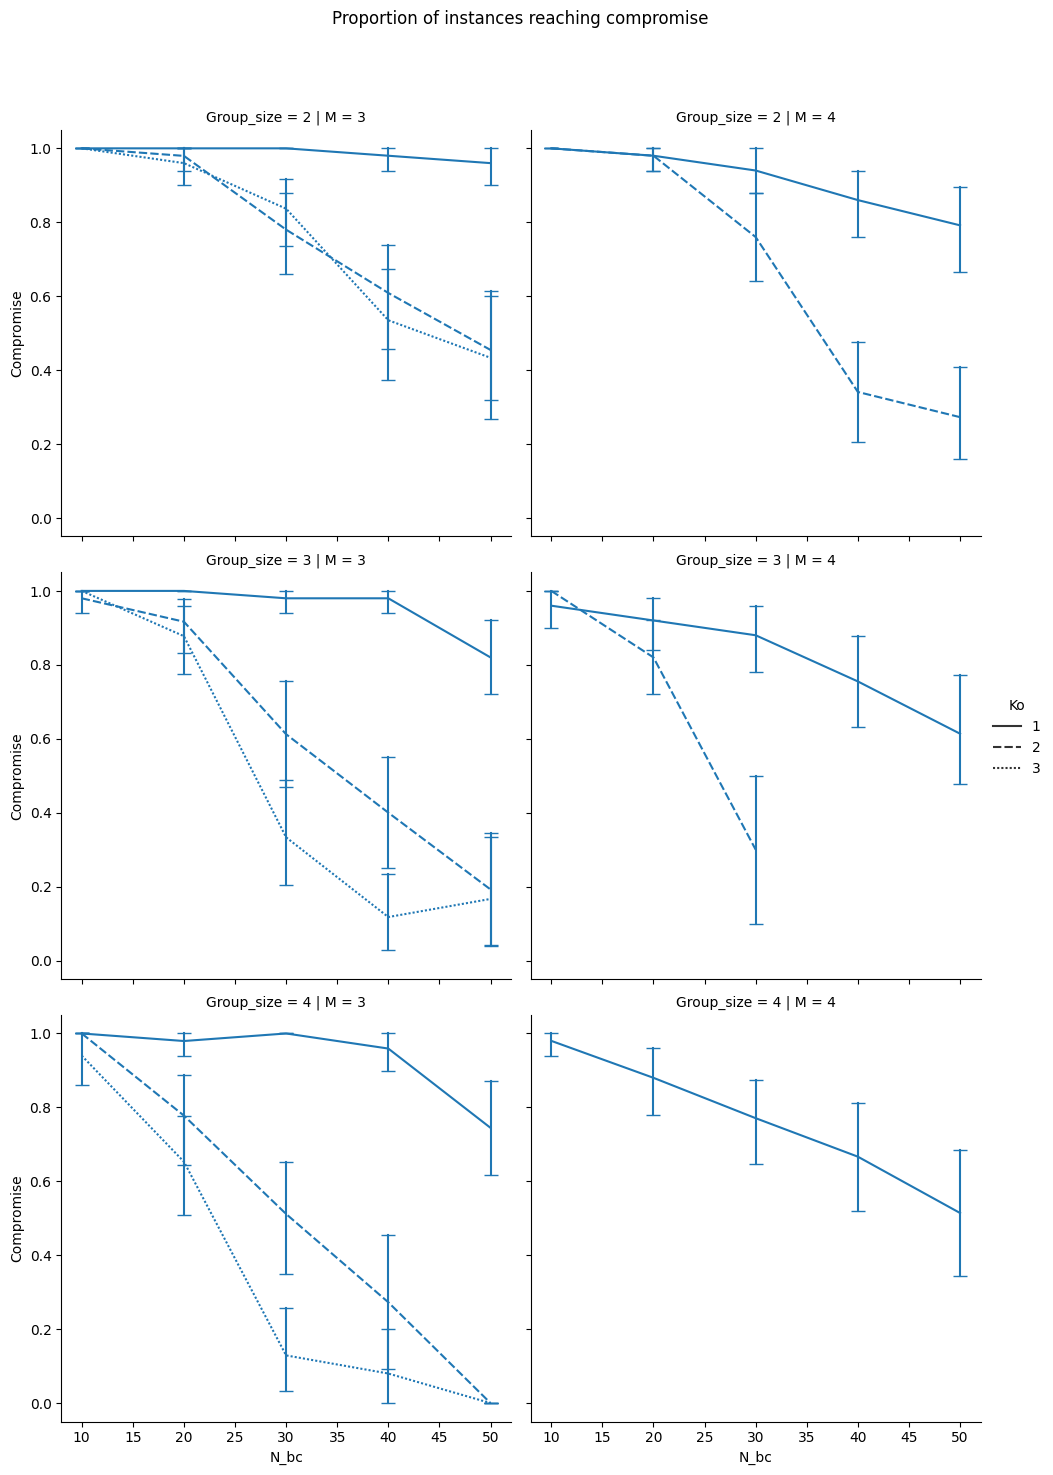

In [13]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="Compromise",
    row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Proportion of instances reaching compromise")

Text(0.5, 0.98, 'Computing time for collective model (MILP)')

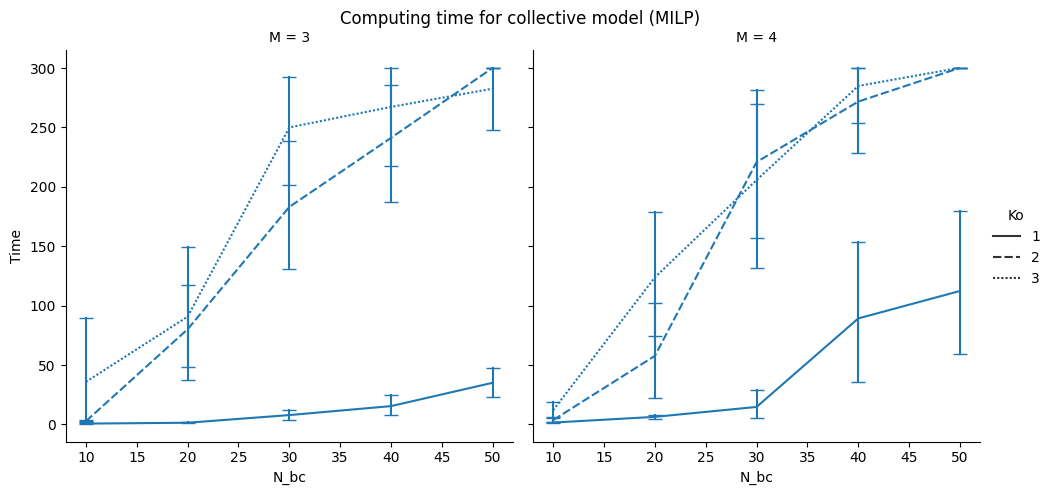

In [38]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for collective model (MILP)")

Text(0.5, 0.98, 'Computing time for preference path')

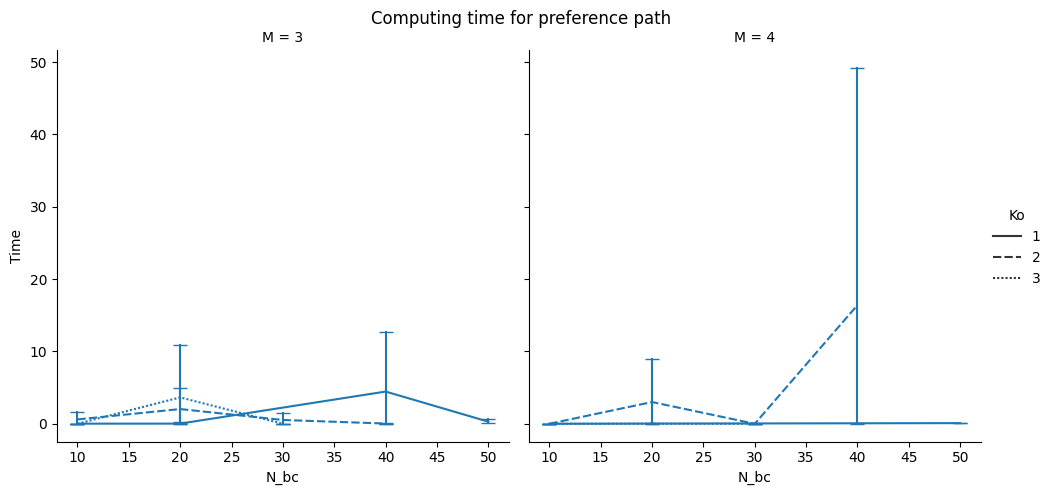

In [36]:
g = sns.relplot(
    df_path,
    x="N_bc",
    y="Time",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Computing time for preference path")

Text(0.5, 0.98, 'Number of iterations')

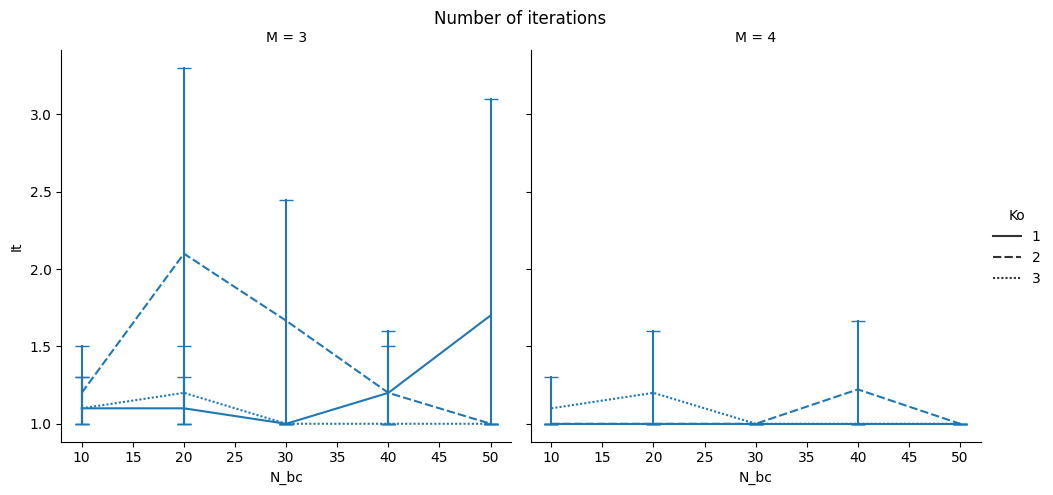

In [24]:
g = sns.relplot(
    dff,
    x="N_bc",
    y="It",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Number of iterations")

Text(0.5, 0.98, 'Max number of comparisons to change for DMs')

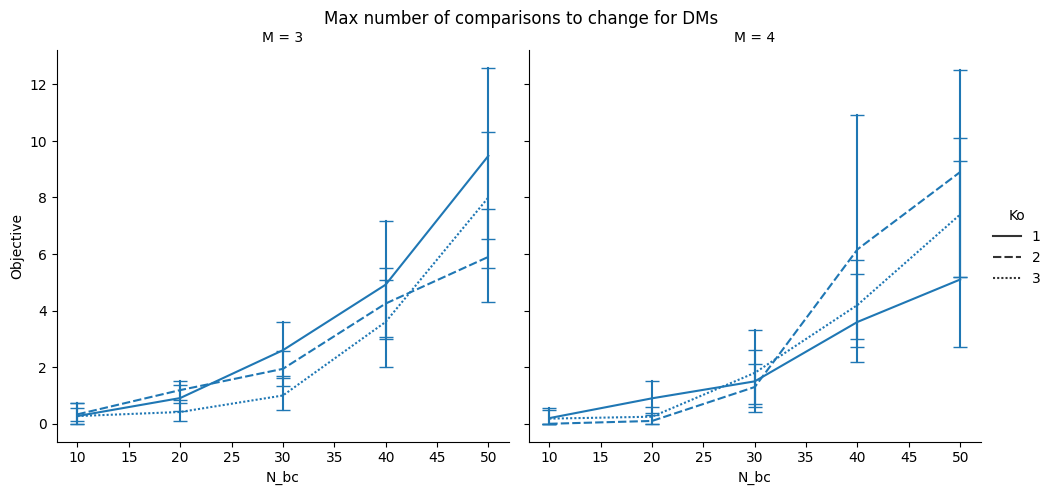

In [37]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max number of comparisons to change for DMs")

Text(0.5, 0.98, 'Max proportion of comparisons to change for DMs')

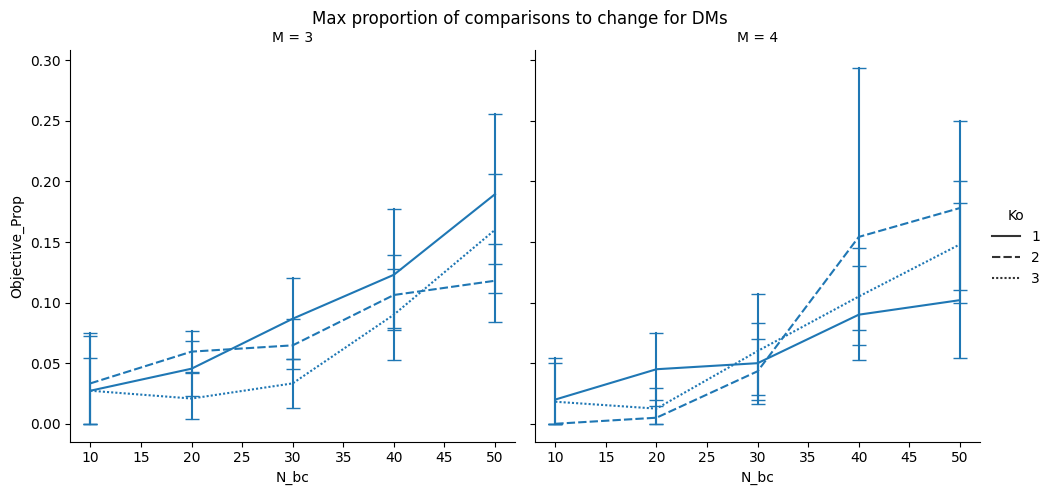

In [31]:
g = sns.relplot(
    df_collective,
    x="N_bc",
    y="Objective_Prop",
    # row="Group_size",
    col="M",
    style="Ko",
    kind="line",
    errorbar=("ci", 95),
    err_style="bars",
    err_kws={"capsize": 5},
)
g.figure.subplots_adjust(top=0.9)
g.figure.suptitle("Max proportion of comparisons to change for DMs")